In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('D:\\KirtiDA_Prep\\Projects\\telecom-network-analytics\\data\\raw\\network_performance.csv')
#if error occure while importing add one extra \ to the address

In [7]:
df.head()

,timestamp,tower_id,users_connected,download_speed,upload_speed,latency,weather,congestion
0,01-01-2025 00:00,1,152,80.671584,9.988305,158.141290,Clear,0
1,01-01-2025 01:00,1,171,19.819479,3.846097,174.573468,Clear,0
2,01-01-2025 02:00,1,713,66.834405,3.764167,147.179767,Snow,0
3,01-01-2025 03:00,1,435,22.273372,9.986821,67.806026,Clear,0
4,01-01-2025 04:00,1,797,7.190930,26.713958,85.973585,Clear,0


In [8]:
df.shape #gives the info about shape of dataset
df.columns # gives all column names
df.info() # gives info about data types and missing values
df.describe(include="all") #gives statistical summary about data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3605 entries, 0 to 3604
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        3605 non-null   object 
 1   tower_id         3605 non-null   int64  
 2   users_connected  3605 non-null   int64  
 3   download_speed   3605 non-null   float64
 4   upload_speed     3605 non-null   float64
 5   latency          3605 non-null   float64
 6   weather          3605 non-null   object 
 7   congestion       3605 non-null   int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 225.4+ KB


,timestamp,tower_id,users_connected,download_speed,upload_speed,latency,weather,congestion
count,3605,3605.00000,3605.000000,3605.000000,3605.000000,3605.000000,3605,3605.000000
unique,721,NaN,NaN,NaN,NaN,NaN,4,NaN
top,01-01-2025 00:00,NaN,NaN,NaN,NaN,NaN,Clear,NaN
freq,5,NaN,NaN,NaN,NaN,NaN,2542,NaN
mean,NaN,3.00000,531.091817,52.087743,25.167230,105.100378,NaN,0.056311
std,NaN,1.41441,275.722937,27.343304,13.995801,54.884409,NaN,0.230553
min,NaN,1.00000,50.000000,5.002918,1.054885,10.033348,NaN,0.000000
25%,NaN,2.00000,294.000000,28.481601,13.380487,58.075005,NaN,0.000000
50%,NaN,3.00000,538.000000,52.514068,25.104473,105.184167,NaN,0.000000
75%,NaN,4.00000,765.000000,75.252828,37.011367,153.865933,NaN,0.000000


In [9]:
missing = df.isnull().sum() #to check the missing values
print(missing)

timestamp          0
tower_id           0
users_connected    0
download_speed     0
upload_speed       0
latency            0
weather            0
congestion         0
dtype: int64


In [12]:
# calculate the missing percentage
missing_pct = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

print(missing_pct)

timestamp          0.0
tower_id           0.0
users_connected    0.0
download_speed     0.0
upload_speed       0.0
latency            0.0
weather            0.0
congestion         0.0
dtype: float64


In [16]:
#check for duplicates
print("Duplicate Rows: ",df.duplicated().sum())

Duplicate Rows:  0


In [ ]:
# to remove duplicates if any
df = df.drop_duplicates()

In [17]:
# to convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

In [29]:
print(df["timestamp"].dtype)

datetime64[ns]


In [18]:
# create new time columns
df["date"] = df["timestamp"].dt.date
df["hour"] = df["timestamp"].dt.hour
df["day_name"] = (df["timestamp"].dt.day_name())

In [19]:
#check for numeric fields
numeric_cols = [
    "users_connected",
    "download_speed",
    "upload_speed",
    "latency"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [21]:
# check for invalid values
print(df[numeric_cols].isnull().sum())

users_connected    0
download_speed     0
upload_speed       0
latency            0
dtype: int64


In [22]:
# save cleaned data
df.to_csv('D:\\KirtiDA_Prep\\Projects\\telecom-network-analytics\\data\\cleaned\\network_performance_cleaned.csv',index = False)

# EDA - Exploratery Data Analysis

In [23]:
# Analysis 1: Average latency
# Which towers have the highest average latency?
avg_latency = (df.groupby("tower_id")["latency"].mean().sort_values(ascending=False))
print(avg_latency.head(10))

tower_id
2    106.618534
5    105.765136
1    105.382381
4    105.265270
3    102.470570
Name: latency, dtype: float64


In [24]:
# Analysis 2: Average download speed
# Which towers have lower download speeds?
avg_speed = (df.groupby("tower_id")["download_speed"].mean().sort_values(ascending=False))
print(avg_speed.head(10))

tower_id
1    52.714215
3    52.387273
4    52.375799
5    52.175325
2    50.786105
Name: download_speed, dtype: float64


In [25]:
# Analysis 3: Congestion rate
# this is overall congestion rate.
congestion_rate = (
    df["congestion"].mean() * 100
)

print(
    f"Congestion rate: {congestion_rate:.2f}%"
)

Congestion rate: 5.63%


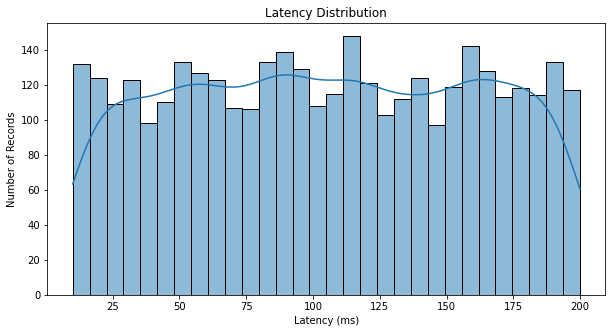

In [26]:
# Analysis 4: Plot latency distribution
plt.figure(figsize=(10,5))
sns.histplot(
    df["latency"].dropna(),
    bins=30,
    kde=True
)

plt.title("Latency Distribution")
plt.xlabel("Latency (ms)")
plt.ylabel("Number of Records")

plt.show()

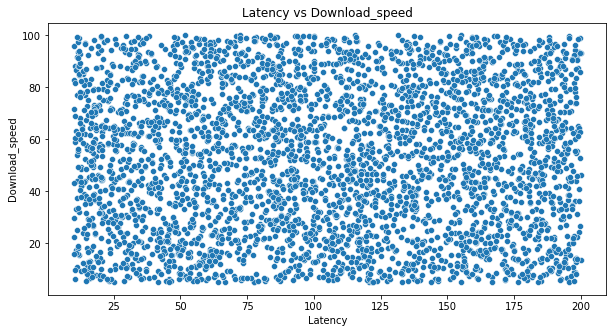

In [27]:
# Analysis 5: Speed vs latency
plt.figure(figsize=(10,5))

sns.scatterplot(data=df, x="latency",y="download_speed")
plt.title("Latency vs Download_speed")
plt.xlabel("Latency")
plt.ylabel("Download_speed") 
plt.show()

In [28]:
# Analysis 6: Performance by hour
hourly = (
    df.groupby("hour")
    .agg(
        avg_latency=("latency", "mean"),
        avg_download_speed=(
            "download_speed", "mean"
        ),
        avg_users=(
            "users_connected", "mean"
        )
    )
    .reset_index()
)

print(hourly)

    hour  avg_latency  avg_download_speed   avg_users
0      0   105.733932           51.915332  555.400000
1      1   107.271227           51.813890  539.520000
2      2   112.882425           51.654276  569.013333
3      3    99.423968           51.457395  527.466667
4      4   107.940639           49.314162  515.806667
5      5   111.368222           50.838991  544.433333
6      6   103.684340           50.890347  557.186667
7      7   106.319594           51.306449  507.233333
8      8    96.160608           54.384548  531.973333
9      9   106.935728           46.140135  518.340000
10    10   106.351574           52.902455  540.453333
11    11   109.964837           52.696728  535.860000
12    12    98.090443           54.021964  532.520000
13    13   100.147413           52.142355  522.073333
14    14   112.961047           50.450233  491.620000
15    15   101.323658           49.022852  537.786667
16    16    99.521284           55.968187  561.760000
17    17   103.604730       

In [31]:
# Create tower-level performance summary

tower_summary = (
    df.groupby("tower_id")
    .agg(
        avg_users=("users_connected", "mean"),
        avg_download_speed=(
            "download_speed", "mean"
        ),
        avg_upload_speed=(
            "upload_speed", "mean"
        ),
        avg_latency=("latency", "mean"),
        congestion_rate=("congestion", "mean")
    )
    .reset_index()
)

# Convert congestion rate to percentage
tower_summary["congestion_rate"] = (
    tower_summary["congestion_rate"] * 100
)

# Round the values for readability
tower_summary = tower_summary.round(2)

# Display the result
tower_summary

,tower_id,avg_users,avg_download_speed,avg_upload_speed,avg_latency,congestion_rate
0,1,516.85,52.71,25.37,105.38,5.41
1,2,544.75,50.79,24.38,106.62,6.24
2,3,524.63,52.39,25.20,102.47,4.58
3,4,537.87,52.38,25.62,105.27,6.66
4,5,531.36,52.18,25.27,105.77,5.27


In [32]:
print(df["timestamp"].dtype)

print(df["timestamp"].min())
print(df["timestamp"].max())

print(df["tower_id"].nunique())

print(df["congestion"].value_counts())

print(tower_summary)

datetime64[ns]
2025-01-01 00:00:00
2025-12-01 23:00:00
5
0    3402
1     203
Name: congestion, dtype: int64
   tower_id  avg_users  avg_download_speed  avg_upload_speed  avg_latency  \
0         1     516.85               52.71             25.37       105.38   
1         2     544.75               50.79             24.38       106.62   
2         3     524.63               52.39             25.20       102.47   
3         4     537.87               52.38             25.62       105.27   
4         5     531.36               52.18             25.27       105.77   

   congestion_rate  
0             5.41  
1             6.24  
2             4.58  
3             6.66  
4             5.27  


In [33]:
# highest letency tower
highest_latency_tower = (
    tower_summary.sort_values(
        "avg_latency",
        ascending=False
    )
    .head(1)
)

highest_latency_tower

,tower_id,avg_users,avg_download_speed,avg_upload_speed,avg_latency,congestion_rate
1,2,544.75,50.79,24.38,106.62,6.24


In [34]:
# highest congestion tower
highest_congestion_tower = (
    tower_summary.sort_values(
        "congestion_rate",
        ascending=False
    )
    .head(1)
)

highest_congestion_tower

,tower_id,avg_users,avg_download_speed,avg_upload_speed,avg_latency,congestion_rate
3,4,537.87,52.38,25.62,105.27,6.66


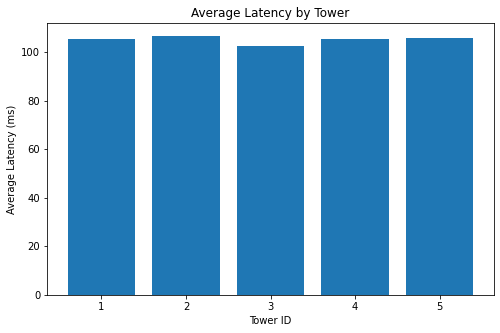

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    tower_summary["tower_id"].astype(str),
    tower_summary["avg_latency"]
)

plt.title("Average Latency by Tower")
plt.xlabel("Tower ID")
plt.ylabel("Average Latency (ms)")

plt.show()

In [36]:
# Number of records per tower

records_per_tower = (
    df.groupby("tower_id")
    .size()
    .reset_index(
        name="record_count"
    )
)

records_per_tower

,tower_id,record_count
0,1,721
1,2,721
2,3,721
3,4,721
4,5,721


In [37]:
# Check unique dates

print(
    "Unique dates:",
    df["date"].nunique()
)

print(
    "Unique timestamps:",
    df["timestamp"].nunique()
)

Unique dates: 31
Unique timestamps: 721


In [38]:
print(tower_summary)

print(highest_latency_tower)

print(highest_congestion_tower)

print(records_per_tower)

   tower_id  avg_users  avg_download_speed  avg_upload_speed  avg_latency  \
0         1     516.85               52.71             25.37       105.38   
1         2     544.75               50.79             24.38       106.62   
2         3     524.63               52.39             25.20       102.47   
3         4     537.87               52.38             25.62       105.27   
4         5     531.36               52.18             25.27       105.77   

   congestion_rate  
0             5.41  
1             6.24  
2             4.58  
3             6.66  
4             5.27  
   tower_id  avg_users  avg_download_speed  avg_upload_speed  avg_latency  \
1         2     544.75               50.79             24.38       106.62   

   congestion_rate  
1             6.24  
   tower_id  avg_users  avg_download_speed  avg_upload_speed  avg_latency  \
3         4     537.87               52.38             25.62       105.27   

   congestion_rate  
3             6.66  
   tower_id  reco

In [ ]:
#Main observations
#Tower 2 has the highest average latency: 106.62.
#Tower 4 has the highest congestion rate: 6.66%.
#Tower 3 has the lowest average latency: 102.47.
#Tower 3 also has the lowest congestion rate: 4.58%.
#Each tower has exactly 721 records, so the tower comparison is balanced.
#Tower 2 has the highest average number of connected users.
#Tower 2 also has the lowest average download and upload speeds.

#Tower 2 shows relatively high network usage and the highest average latency, while Tower 4 records the highest congestion rate.
#These towers may require further investigation during peak usage periods.

In [39]:
# Hourly summary
hourly_summary = (
    df.groupby("hour")
    .agg(
        avg_users=("users_connected", "mean"),
        avg_download_speed=("download_speed", "mean"),
        avg_upload_speed=("upload_speed", "mean"),
        avg_latency=("latency", "mean"),
        congestion_rate=("congestion", "mean")
    )
    .reset_index()
)

hourly_summary["congestion_rate"] = (
    hourly_summary["congestion_rate"] * 100
)

hourly_summary = hourly_summary.round(2)

hourly_summary

,hour,avg_users,avg_download_speed,avg_upload_speed,avg_latency,congestion_rate
0,0,555.40,51.92,24.62,105.73,7.10
1,1,539.52,51.81,26.18,107.27,9.33
2,2,569.01,51.65,25.93,112.88,7.33
3,3,527.47,51.46,23.65,99.42,4.67
4,4,515.81,49.31,24.06,107.94,2.67
5,5,544.43,50.84,25.32,111.37,9.33
6,6,557.19,50.89,26.37,103.68,7.33
7,7,507.23,51.31,26.01,106.32,6.67
8,8,531.97,54.38,24.41,96.16,3.33
9,9,518.34,46.14,23.68,106.94,5.33


In [40]:
# Busiest hour
busiest_hour = (
    hourly_summary
    .sort_values("avg_users", ascending=False)
    .head(1)
)

busiest_hour

,hour,avg_users,avg_download_speed,avg_upload_speed,avg_latency,congestion_rate
2,2,569.01,51.65,25.93,112.88,7.33


In [41]:
highest_latency_hour = (
    hourly_summary
    .sort_values("avg_latency", ascending=False)
    .head(1)
)

highest_latency_hour

,hour,avg_users,avg_download_speed,avg_upload_speed,avg_latency,congestion_rate
14,14,491.62,50.45,26.44,112.96,4.67


In [42]:
highest_congestion_hour = (
    hourly_summary
    .sort_values("congestion_rate", ascending=False)
    .head(1)
)

highest_congestion_hour

,hour,avg_users,avg_download_speed,avg_upload_speed,avg_latency,congestion_rate
18,18,551.67,58.14,23.47,112.5,11.33


In [44]:
# to check whether every tower has same number of records per hour
hour_tower_check = (
    df.groupby(["tower_id", "hour"])
    .size()
    .reset_index(name="record_count")
)

hour_tower_check.head(20)

,tower_id,hour,record_count
0,1,0,31
1,1,1,30
2,1,2,30
3,1,3,30
4,1,4,30
5,1,5,30
6,1,6,30
7,1,7,30
8,1,8,30
9,1,9,30


In [45]:
print(hourly_summary)

print("Busiest hour:")
print(busiest_hour)

print("Highest latency hour:")
print(highest_latency_hour)

print("Highest congestion hour:")
print(highest_congestion_hour)

print("Unique calendar dates:")
print(df["timestamp"].dt.date.nunique())

print("Records by month:")
print(df["timestamp"].dt.month.value_counts().sort_index())

    hour  avg_users  avg_download_speed  avg_upload_speed  avg_latency  \
0      0     555.40               51.92             24.62       105.73   
1      1     539.52               51.81             26.18       107.27   
2      2     569.01               51.65             25.93       112.88   
3      3     527.47               51.46             23.65        99.42   
4      4     515.81               49.31             24.06       107.94   
5      5     544.43               50.84             25.32       111.37   
6      6     557.19               50.89             26.37       103.68   
7      7     507.23               51.31             26.01       106.32   
8      8     531.97               54.38             24.41        96.16   
9      9     518.34               46.14             23.68       106.94   
10    10     540.45               52.90             26.95       106.35   
11    11     535.86               52.70             26.60       109.96   
12    12     532.52               54.0

In [ ]:
# findings
#The 6 PM period records the highest congestion rate at 11.33%. 
#The 2 AM period has the highest average user count, while the 2 PM period has the highest average latency. 
#These results indicate that user volume, latency, and congestion do not always peak at the same time.

In [46]:
df["timestamp_date_check"] = df["timestamp"].dt.date.astype(str)

date_mismatch = df[
    df["date"] != df["timestamp_date_check"]
]

print("Date mismatches:", len(date_mismatch))

date_mismatch.head()

Date mismatches: 3605


,timestamp,tower_id,users_connected,download_speed,upload_speed,latency,weather,congestion,date,hour,day_name,timestamp_date_check
0,2025-01-01 00:00:00,1,152,80.671584,9.988305,158.141290,Clear,0,2025-01-01,0,Wednesday,2025-01-01
1,2025-01-01 01:00:00,1,171,19.819479,3.846097,174.573468,Clear,0,2025-01-01,1,Wednesday,2025-01-01
2,2025-01-01 02:00:00,1,713,66.834405,3.764167,147.179767,Snow,0,2025-01-01,2,Wednesday,2025-01-01
3,2025-01-01 03:00:00,1,435,22.273372,9.986821,67.806026,Clear,0,2025-01-01,3,Wednesday,2025-01-01
4,2025-01-01 04:00:00,1,797,7.190930,26.713958,85.973585,Clear,0,2025-01-01,4,Wednesday,2025-01-01
